In [15]:
import nilearn.plotting
from nilearn import plotting 

plotting.view_img('/Users/zach/2025_RA/matthias/final images/tmaps/wake_tmap_group.nii.gz', threshold=1)

KeyboardInterrupt: 

In [1]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    # exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=True,
    load_eog=False,
    desc_add="clean-with-fd-clamped",
)
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)

desc_add = f"{desc_add}-{config.second_level.method}"

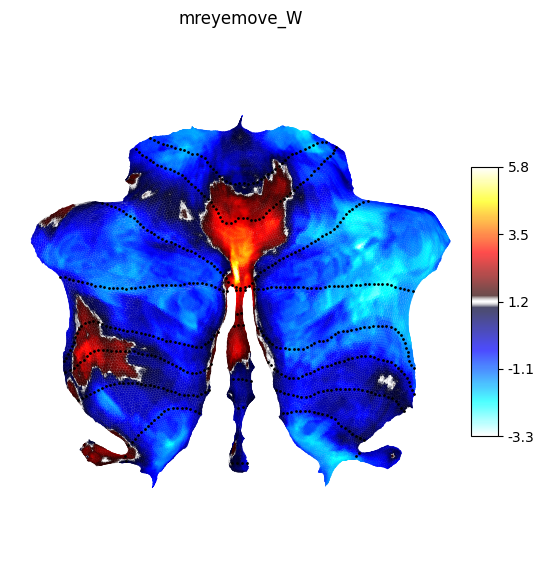

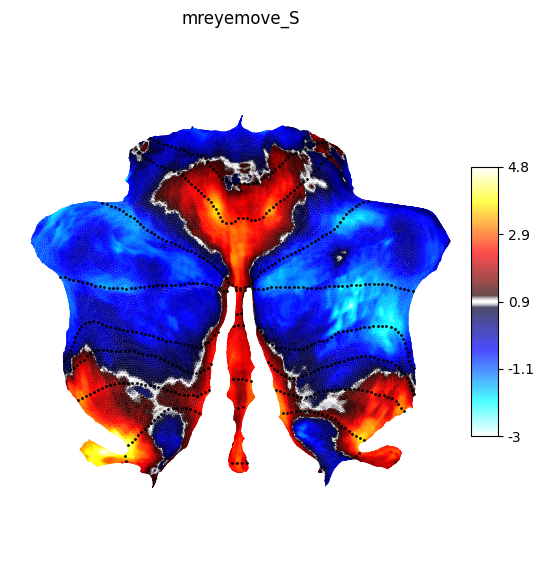

In [2]:
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap
from nilearn import image
# Import necessary packages
from nilearn import plotting
import nibabel as nib
from SUITPy import flatmap
import SUITPy as suit
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)

desc_add = f"{desc_add}-{config.second_level.method}"
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/') 
output_dir.mkdir(parents=True, exist_ok=True)

for state in ("W", "S"):
    contrast = f"mreyemove_{state}"
    output_path = output_dir / f"{contrast}.png"
    if config.second_level.method == "flame":
        data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
    elif config.second_level.method == "randomise":
        data, _ = mrio.load_randomise_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat_neg, space='FSL')
    ax = flatmap.plot(data=funcdata, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',)
        # cscale=[-8, 8],)
    ax.set_title(contrast)
    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")

In [37]:
import pandas as pd

df = pd.read_json("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/qc/run_inclusion/clean-with-fd-clamped-20260501-13431777635836.json", lines=True)

# Fix bool strings if you haven't already
for col in ["excluded"]:
    if df[col].dtype == object:
        df[col] = df[col].map({"True": True, "False": False})


In [38]:
print(len(df) - len(df[df["excluded"]==True]))

print(len(df))
print(len(df[df["excluded"]==True]))

297
352
55


In [45]:
df[df["excluded"]].subject.unique()

array([ 9, 17, 32,  8, 11, 23,  7, 16, 14, 13, 12,  3,  4, 27, 31, 20, 28])

In [39]:

fl = df.query("stage == 'first_level_glm'")

# Per subject: did any run survive?
survival = fl.groupby("subject")["excluded"].agg(
    n_runs="count",
    n_excluded="sum",
)
survival["all_lost"] = survival["n_runs"] == survival["n_excluded"]

print(survival.query("all_lost"))

         n_runs  n_excluded  all_lost
subject                              
3             8           8      True
9             5           5      True
12            3           3      True


In [43]:
glob = df.query("stage == 'global'")
glob_survival = glob.groupby("subject")["excluded"].agg(
    n_runs="count",
    n_excluded="sum",
)
glob_survival["all_lost_global"] = (
    glob_survival["n_runs"] == glob_survival["n_excluded"]
)

# Combine
combined = glob_survival.join(survival, lsuffix="_global", rsuffix="_fl", how="outer")
print(combined)

pythoncer = df.query(
    "stage == 'first_level_glm'"
)
fully_lost = cer.groupby("subject")["excluded"].all()
fully_lost = fully_lost[fully_lost].index.tolist()
print(f"Fully lost for cerebellar: {fully_lost}")

         n_runs_global  n_excluded_global  all_lost_global  n_runs_fl  \
subject                                                                 
1                    3                  0            False          3   
3                    8                  0            False          8   
4                    7                  1            False          6   
5                    6                  0            False          6   
6                    4                  0            False          4   
7                    5                  3            False          2   
8                    7                  0            False          7   
9                    6                  1            False          5   
10                   6                  0            False          6   
11                   6                  4            False          2   
12                   3                  0            False          3   
13                   4                  2          

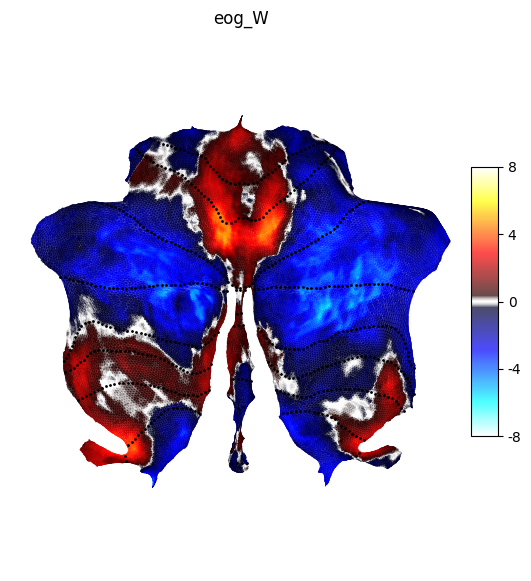

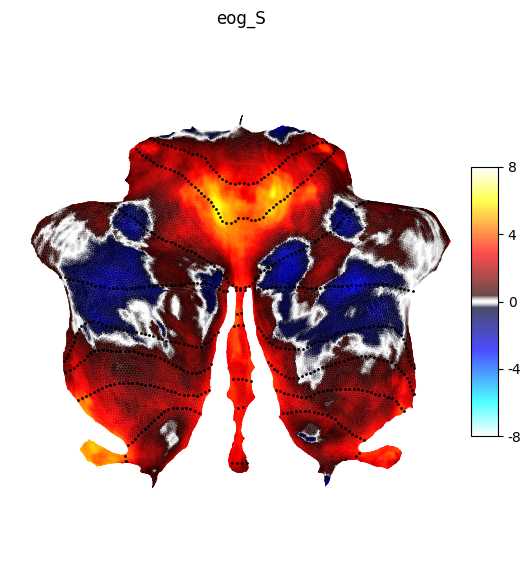

In [3]:
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap
from nilearn import image
# Import necessary packages
from nilearn import plotting
import nibabel as nib
from SUITPy import flatmap
import SUITPy as suit
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/eog_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)

desc_add = f"{desc_add}-{config.second_level.method}"
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/eog/') 
output_dir.mkdir(parents=True, exist_ok=True)

for state in ("W", "S"):
    contrast = f"eog_{state}"
    output_path = output_dir / f"{contrast}.png"
    if config.second_level.method == "flame":
        data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
    elif config.second_level.method == "randomise":
        data, _ = mrio.load_randomise_result(contrast=contrast, desc_add=desc_add)
        funcdata = flatmap.vol_to_surf(data.t_stat_neg, space='FSL')
    ax = flatmap.plot(data=funcdata, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-8, 8],)
    ax.set_title(contrast)
    ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_10536/3570557525.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  data = image.mean_img(mrio.load_functional_image(subject=subject, run=run)[0])
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_10536/3570557525.py:12: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(data, cmap=custom_cmap(), threshold=0.1, symmetric_cmap=True, width_view=1000)



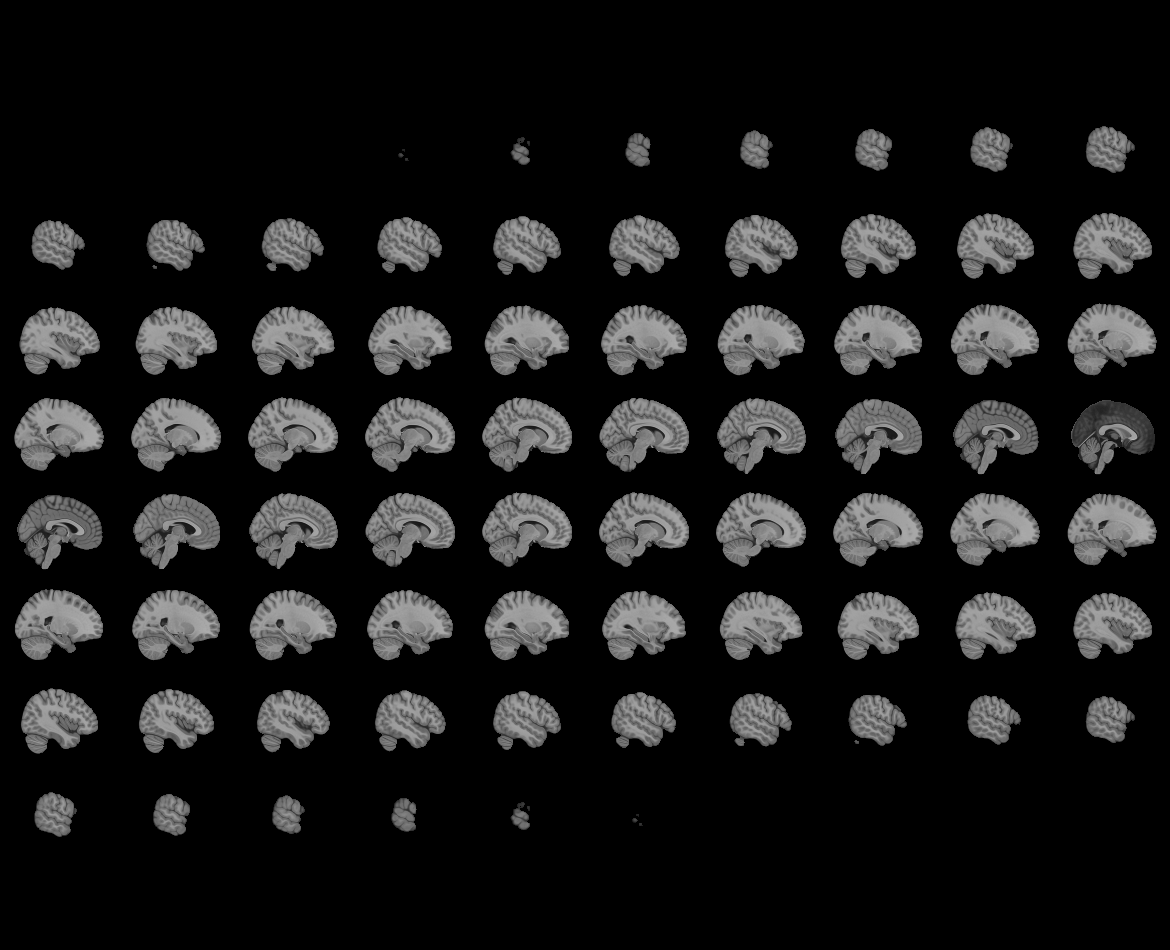
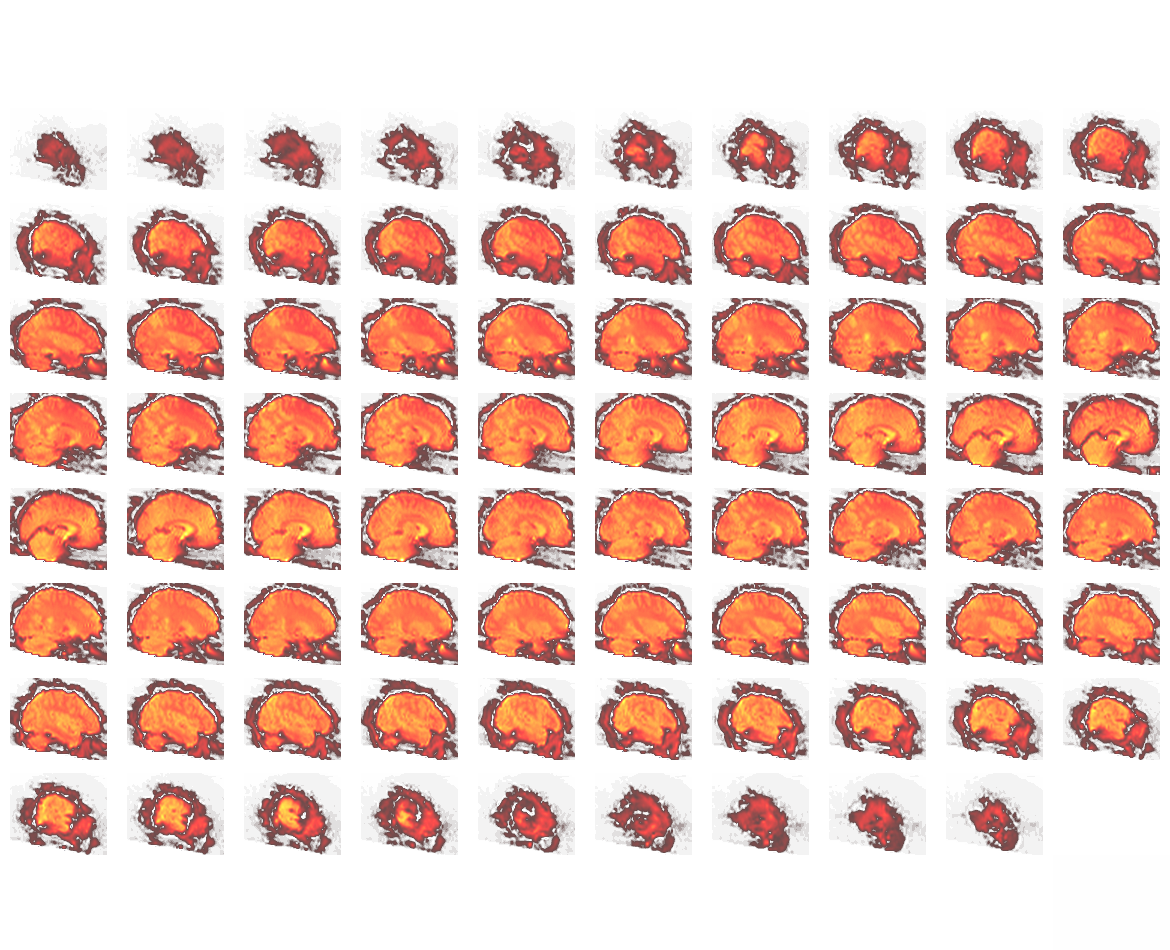

In [95]:

from nilearn import plotting, image

subject = "03"
run = "4"
contrast = "mreyemove_W"
config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
data = image.mean_img(mrio.load_functional_image(subject=subject, run=run)[0]) 
# bg = mrio.load_
# data[contrast].stat
# plotting.view_img(data[contrast].stat, cmap=custom_cmap(), threshold=0.1, symmetric_cmap=True, width_view=1000)
plotting.view_img(data, cmap=custom_cmap(), threshold=0.1, symmetric_cmap=True, width_view=1000)
# funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
# 
# flatmap.plot(data=funcdata, cmap=custom_cmap(), 
#     new_figure=True, 
#     colorbar=True, 
#     render='matplotlib',
#              cscale=[-7, 7])

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_27263/3801760233.py:5: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  plotting.view_img(mask)



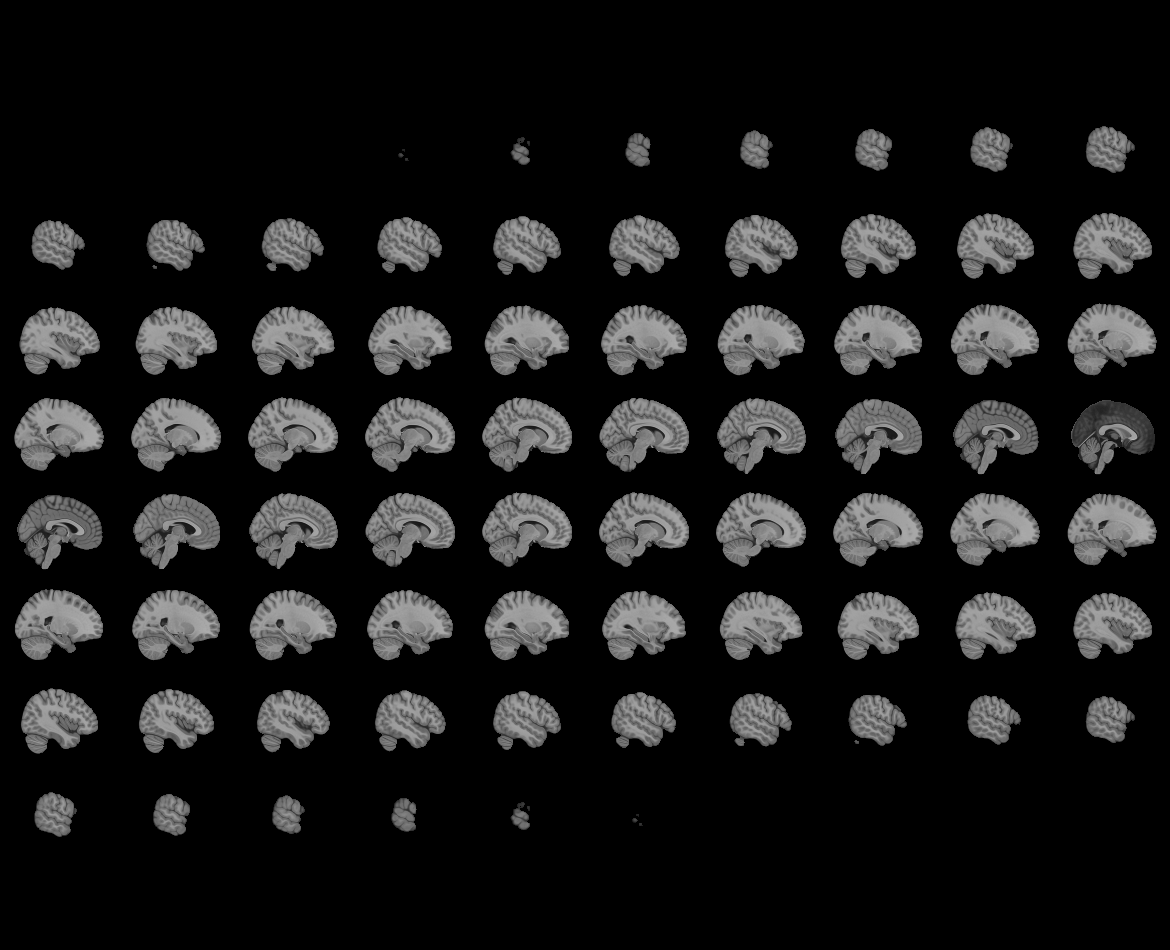
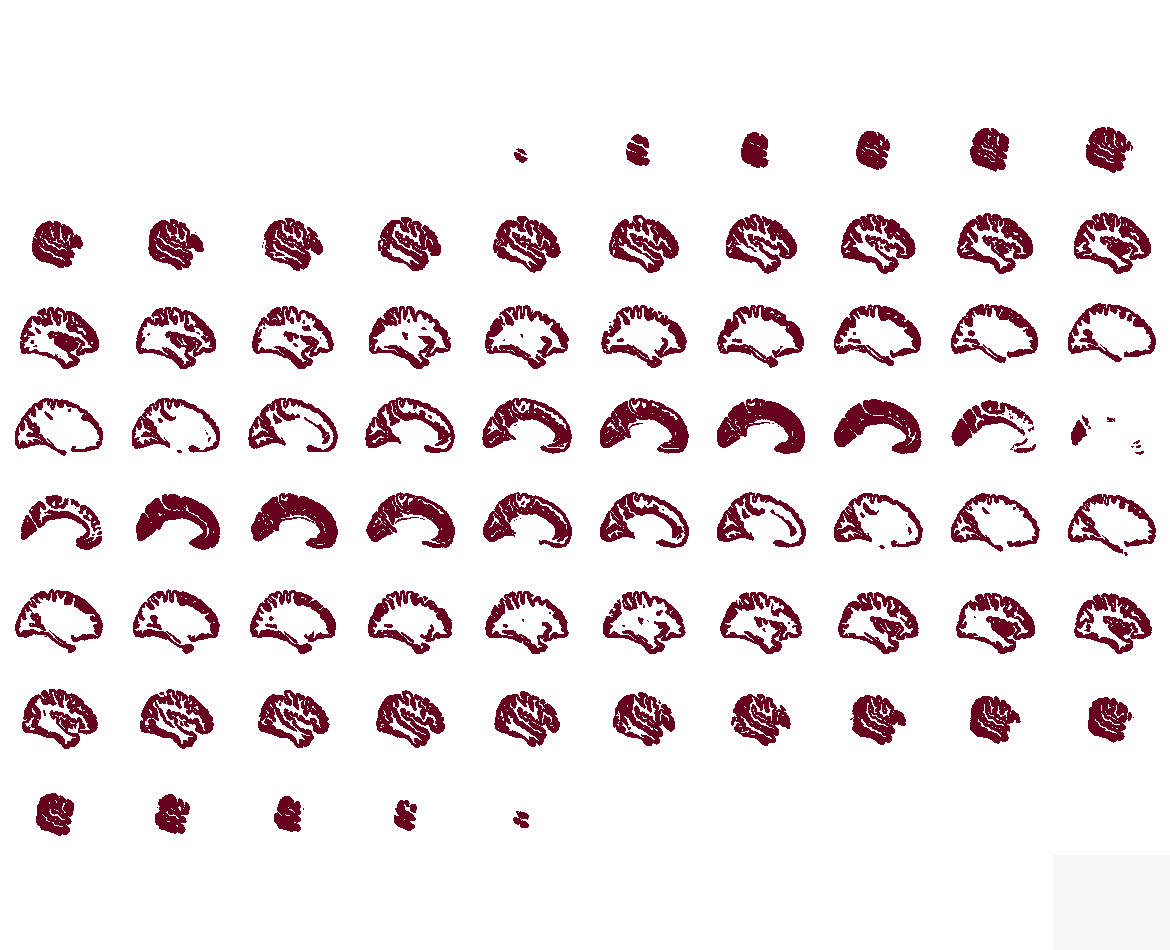

In [3]:
from mreyemove.analysis.glm.mask_coverage import _load_reference_mask
from nilearn import plotting 

mask = _load_reference_mask(atlas="glasser")
plotting.view_img(mask)

In [114]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from pathlib import Path
from nilearn import datasets
import os 
from SUITPy import flatmap
from mreyemove.analysis.glm.atlas import fetch_atlas

# === Config ===
SUBJECTS = [f'sub-{i:02d}' for i in range(1, 21)]  # adapt
TASK_PATTERN = '*'        # e.g. 'sleep' or '*' for all tasks
THRESHOLD = 0.90
OUTDIR = Path('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/qc/cerebellum_coverage')
OUTDIR.mkdir(exist_ok=True)


import os
fsl_cereb = Path(os.environ['FSLDIR']) / 'data/atlases/Cerebellum/Cerebellum-MNIfnirt-maxprob-thr25-2mm.nii.gz'
cereb_img = nib.load(fsl_cereb)
cereb_data = cereb_img.get_fdata()
print(f'Cerebellar mask: {cereb_data.sum()} voxels')
# plotting.view_img(atlas_img)
# labels = ho.labels
# print(ho.labels)
# # Find cerebellar labels
# cereb_idx = [i for i, l in enumerate(labels) if 'erebell' in l.lower()]
# print([labels[i] for i in cereb_idx])  # check what you got
# 
# atlas_img = nib.load(ho.maps) if isinstance(ho.maps, str) else ho.maps
# atlas_data = atlas_img.get_fdata()
# cereb_mask = np.isin(atlas_data, cereb_idx).astype(np.uint8)
# cereb_img = nib.Nifti1Image(cereb_mask, atlas_img.affine, atlas_img.header)
# cereb_data = cereb_img.get_fdata()
# vox_vol = np.prod(cereb_img.header.get_zooms()[:3])
# print(f'Cerebellar mask: {cereb_data.sum()} voxels, '
#       f'{cereb_data.sum() * vox_vol / 1000:.1f} cm³')
# 
# fsl_cereb.exists()

Cerebellar mask: 248490.0 voxels


In [127]:
 Path(os.environ['FSLDIR'])

PosixPath('/Users/zach/fsl')


Per-subject cerebellar coverage:
subject  min_cov  mean_cov  n_runs
     09 0.337372  0.399276       6
     12 0.660539  0.716245       3
     13 0.783998  0.883173       4
     32 0.816587  0.876071       8
     17 0.824316  0.900325       7
     03 0.830792  0.852047       8
     31 0.830792  0.885558       6
     14 0.892626  0.905070       7
     08 0.898893  0.913426       7
     11 0.909338  0.933605       6
     18 0.914351  0.927052       5
     30 0.918738  0.936425       6
     01 0.922081  0.931690       3
     15 0.923543  0.942588       6
     24 0.925632  0.932386       6
     25 0.932943  0.939176       6
     07 0.935450  0.948485       5
     04 0.938793  0.945328       7
     23 0.942762  0.951065       8
     20 0.948193  0.952496       5
     27 0.948402  0.959682       7
     19 0.952162  0.955881       5
     33 0.958638  0.963443       7
     16 0.960936  0.971955       8
     05 0.961354  0.967481       6
     28 0.962816  0.976360       6
     10 0.970963  0.9

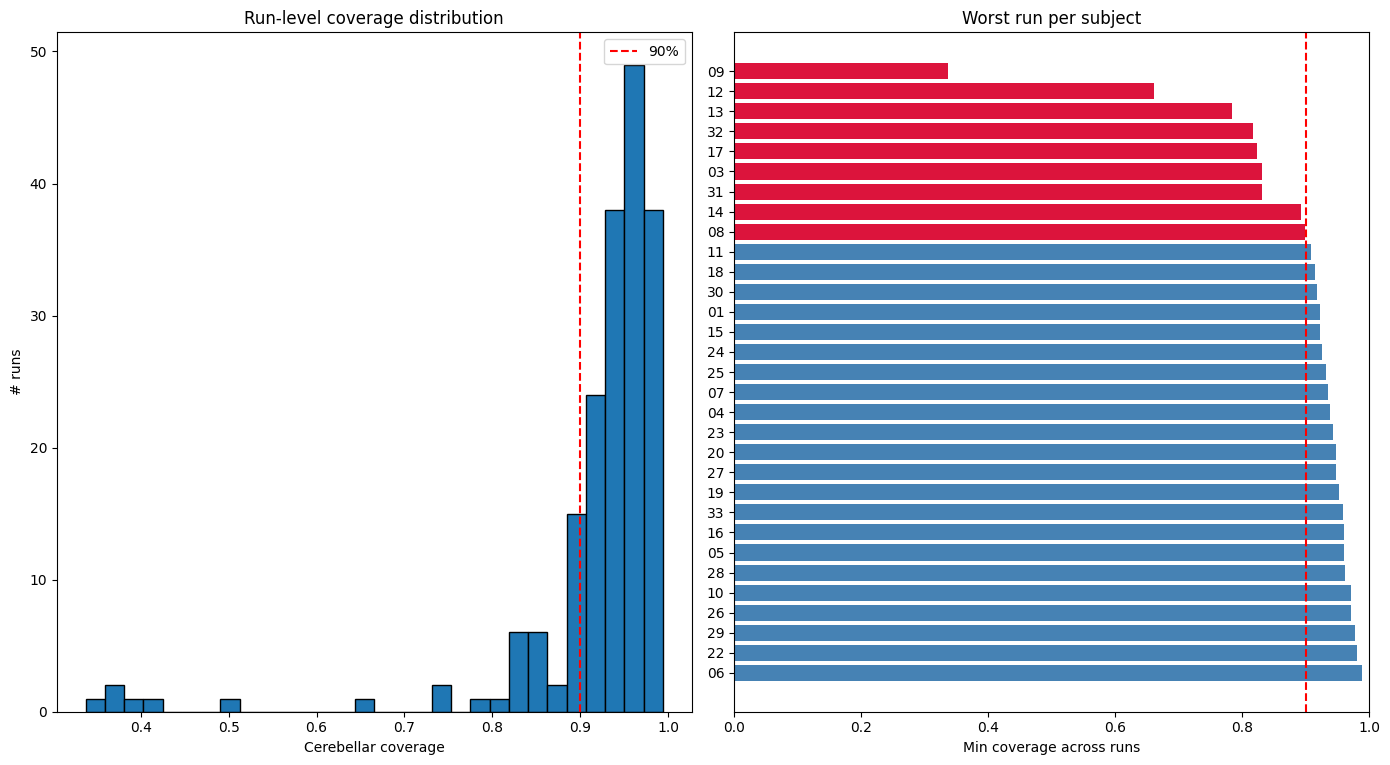


Subjects with min coverage < 90%:
subject  min_cov  mean_cov  n_runs
     09 0.337372  0.399276       6
     12 0.660539  0.716245       3
     13 0.783998  0.883173       4
     32 0.816587  0.876071       8
     17 0.824316  0.900325       7
     03 0.830792  0.852047       8
     31 0.830792  0.885558       6
     14 0.892626  0.905070       7
     08 0.898893  0.913426       7

Individual runs below threshold:
subject session run  coverage
     03    None   1  0.875705
     03    None   2  0.866931
     03    None   3  0.850428
     03    None   4  0.843326
     03    None   5  0.847504
     03    None   6  0.830792
     03    None   7  0.848548
     03    None   8  0.853144
     08    None   1  0.898893
     09    None   1  0.511176
     09    None   2  0.362858
     09    None   3  0.337372
     09    None   4  0.377272
     09    None   5  0.387090
     09    None   6  0.419887
     12    None   1  0.735743
     12    None   2  0.752455
     12    None   3  0.660539
     13    

In [12]:
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from pathlib import Path
from nilearn import datasets
import os 
from SUITPy import flatmap


# === Config ===
SUBJECTS = [f'sub-{i:02d}' for i in range(1, 21)]  # adapt
TASK_PATTERN = '*'        # e.g. 'sleep' or '*' for all tasks
THRESHOLD = 0.9
OUTDIR = Path('/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/qc/cerebellum_coverage')
OUTDIR.mkdir(exist_ok=True)


cereb_img = _load_reference_mask(atlas="cer_fsl")


# === Compute coverage per run ===
records = []
for subject, run, run_df in mrio.iter_run_events(run_exclusion=False):
    sub_mask_img, file_path = mrio.load_brain_mask(subject, run)

    # Resample cerebellar mask onto subject EPI grid (NN for binary)
    cereb_rs = resample_to_img(
        cereb_img, sub_mask_img,
        interpolation='nearest', force_resample=True, copy_header=True,
    )
    cereb_rs_data = cereb_rs.get_fdata() > 0
    sub_mask_data = sub_mask_img.get_fdata() > 0

    denom = cereb_rs_data.sum()
    numer = np.logical_and(cereb_rs_data, sub_mask_data).sum()
    coverage = numer / denom if denom > 0 else np.nan

    # Parse run/ses from filename
    stem = Path(file_path).name.split('.')[0]  # strip all extensions (.nii.gz)
    parts =  dict(p.split('-', 1) for p in stem.split('_') if '-' in p)

    records.append({
        'subject': subject,
        'session': parts.get('ses'),
        'task': parts.get('task'),
        'run': parts.get('run'),
        'coverage': coverage,
        'file': file_path.name,
    })

df = pd.DataFrame(records).sort_values(['subject', 'session', 'run'])
df.to_csv(OUTDIR / 'coverage_per_run.csv', index=False)

# === Per-subject summary (worst run drives inclusion) ===
subj = (df.groupby('subject')['coverage']
          .agg(min_cov='min', mean_cov='mean', n_runs='count')
          .reset_index()
          .sort_values('min_cov'))
subj.to_csv(OUTDIR / 'coverage_per_subject.csv', index=False)
print('\nPer-subject cerebellar coverage:')
print(subj.to_string(index=False))

# === Plot ===
fig, axes = plt.subplots(1, 2, figsize=(14, max(4, 0.25 * len(subj))))

axes[0].hist(df['coverage'].dropna(), bins=30, edgecolor='k')
axes[0].axvline(THRESHOLD, color='r', ls='--', label=f'{THRESHOLD:.0%}')
axes[0].set(xlabel='Cerebellar coverage', ylabel='# runs',
            title='Run-level coverage distribution')
axes[0].legend()

axes[1].barh(subj['subject'], subj['min_cov'],
             color=['crimson' if c < THRESHOLD else 'steelblue'
                    for c in subj['min_cov']])
axes[1].axvline(THRESHOLD, color='r', ls='--')
axes[1].set(xlabel='Min coverage across runs',
            title='Worst run per subject', xlim=(0, 1))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


# === Flag bad subjects/runs ===
bad_subj = subj.query('min_cov < @THRESHOLD')
bad_runs = df.query('coverage < @THRESHOLD')
print(f'\nSubjects with min coverage < {THRESHOLD:.0%}:')
print(bad_subj.to_string(index=False))
print(f'\nIndividual runs below threshold:')
print(bad_runs[['subject', 'session', 'run', 'coverage']].to_string(index=False))

In [14]:
df.query('subject in ["09", "12", "13", "32", "17", "03", "31"]')[
    ['subject', 'run', 'coverage']
].sort_values(['coverage']).reset_index(drop=True)

,subject,run,coverage
0,09,3,0.337372
1,09,2,0.362858
2,09,4,0.377272
3,09,5,0.387090
4,09,6,0.419887
5,09,1,0.511176
6,12,3,0.660539
7,12,1,0.735743
8,12,2,0.752455
9,13,4,0.783998


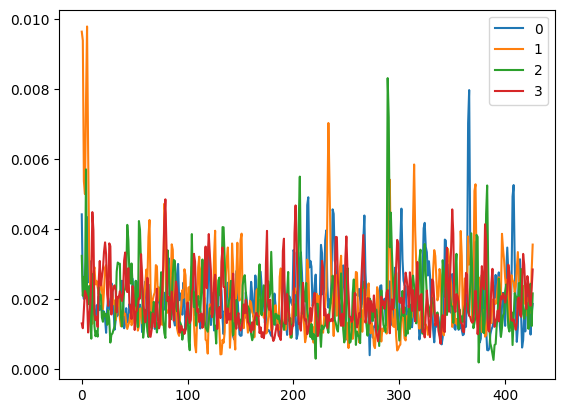

In [82]:

from matplotlib import pyplot as plt

ems = [run_df["mreyemove"].values.T for subject, run, run_df in mrio.iter_run_events(subject="09", run_inclusion=True)]
# ems[0]
for i, em in enumerate(ems):
    if i != 4:
        plt.plot(em, label=i)
    
plt.legend()

/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_15817/2465599252.py:4: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)



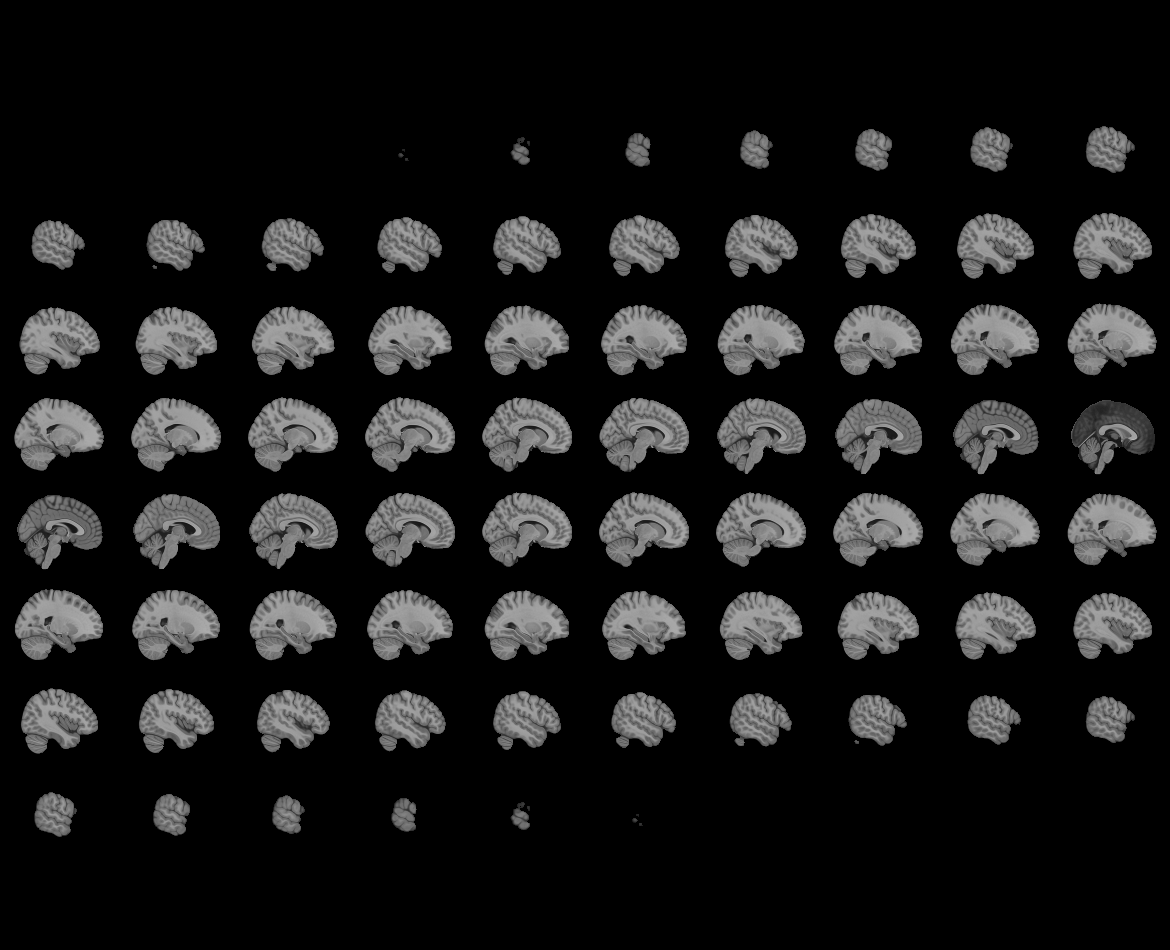
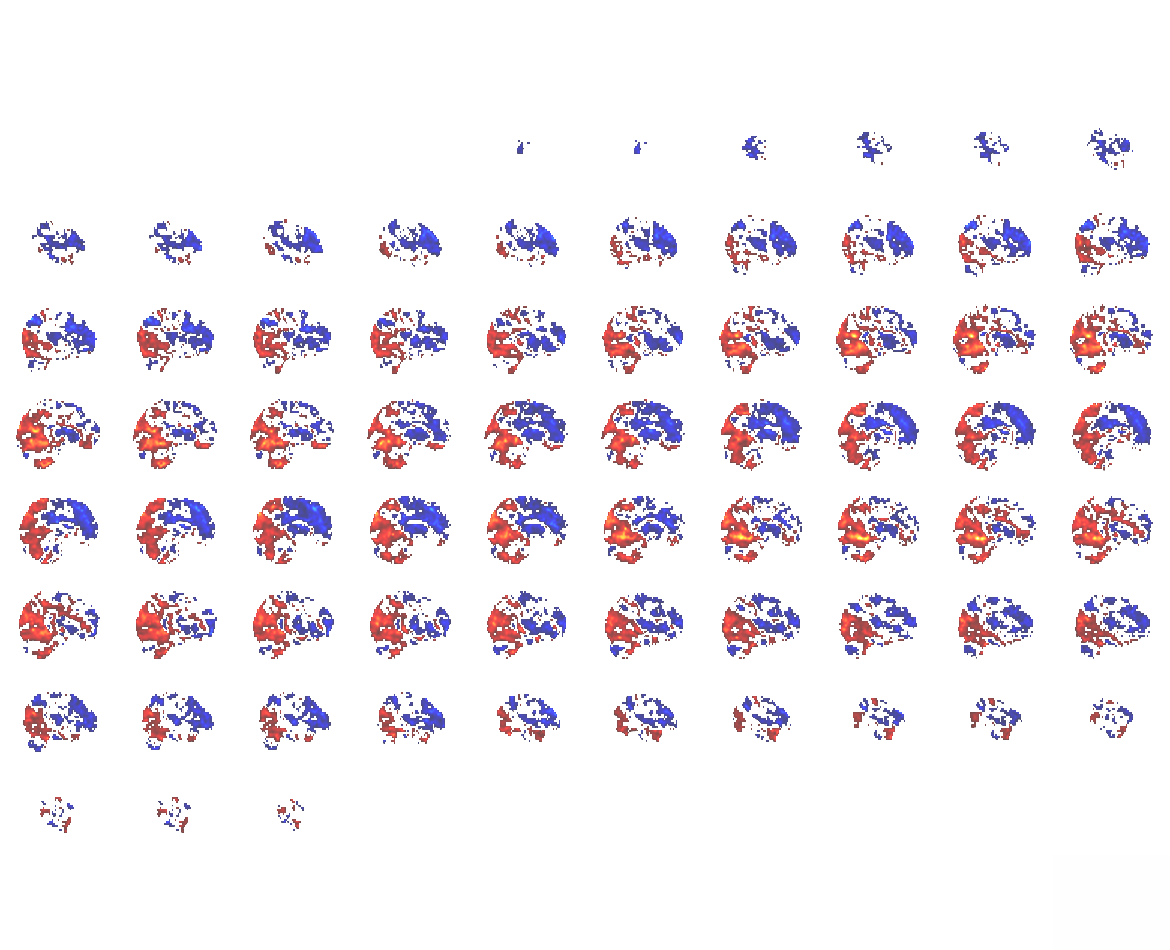

In [29]:
from nilearn import plotting 
contrast = "mreyemove_S"
data, _ = mrio.load_FLAME_result(contrast=contrast, desc_add=desc_add)
plotting.view_img(data.t_stat, cmap=custom_cmap(), threshold=1, symmetric_cmap=True, width_view=1000)
# funcdata = flatmap.vol_to_surf(data.t_stat, space='FSL')
# 
# flatmap.plot(data=funcdata, cmap=custom_cmap(), 
#     new_figure=True, 
#     colorbar=True, 
#     render='matplotlib',
#              cscale=[-7, 7])

In [3]:

from pathlib import Path
from scipy.stats import spearmanr
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from tqdm.auto import trange
import numpy as np
import gdist
from nilearn.surface import load_surf_mesh, vol_to_surf, load_surf_data
from nilearn import datasets, plotting
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mreyemove.plotting.glm import custom_cmap
from nilearn.plotting.surface._matplotlib_backend import (
    _plot_surf,
    _get_ticks,
    _colorbar_from_array,
)
from nilearn.plotting.surface._utils import check_surface_plotting_inputs


def geodesic_neighborhoods(coords, faces, radius_mm=9.0, chunk_size=500):
    """
    Approximate geodesic neighborhoods using Dijkstra shortest paths
    on the mesh edge graph (Chen et al., 2011).
    Returns an array of shape (n,) where each entry i is an array 
    of indices less than radius_mm away from vertex i in the graph 
    """
    n = len(coords)
    # faces = faces.astype(np.int32)

    # Build weighted adjacency graph from mesh edges (vectorized)
    
    # Extract triangle vertices (from faces) to construct a list of pairwise edges
    edges = np.vstack([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [0, 2]]])
    
    # Compute norm (magnitude) of distance between edges
    dists = np.linalg.norm(coords[edges[:, 0]] - coords[edges[:, 1]], axis=1)
    
    # Construct graph, edges in both directions
    graph = csr_matrix(
        (np.concatenate([dists, dists]),
         (np.concatenate([edges[:, 0], edges[:, 1]]),
          np.concatenate([edges[:, 1], edges[:, 0]]))),
        shape=(n, n),
    )

    # Chunked Dijkstra with distance cutoff
    neighborhoods = [None] * n
    for start in trange(0, n, chunk_size, desc="Dijkstra neighborhoods"):
        end = min(start + chunk_size, n)
        dist_chunk = dijkstra(
            graph, directed=False,
            indices=np.arange(start, end),
            limit=radius_mm,
        )
        for local_i in range(end - start):
            # Collect indices where distances are not None (and therefore lower than radius_mm)
            neighborhoods[start + local_i] = np.where(np.isfinite(dist_chunk[local_i]))[0]

    return neighborhoods


def surface_searchlight_correlation(
    map_a_surf: np.ndarray,
    map_b_surf: np.ndarray,
    coords: np.ndarray,
    faces: np.ndarray,
    radius_mm: float = 10.0,
    min_vertices: int = 10,
) -> np.ndarray:
    """
    Compute searchlight Pearson correlation between two surface maps
    using geodesic neighborhoods (Dijkstra on mesh graph).
    """
    print(f"Building geodesic neighborhoods (radius={radius_mm}mm)...")
    neighborhoods = geodesic_neighborhoods(coords, faces, radius_mm=radius_mm)

    neighbor_counts = np.array([len(n) for n in neighborhoods])
    print(f"Neighbors — Mean: {neighbor_counts.mean():.0f}, "
          f"Median: {np.median(neighbor_counts):.0f}, "
          f"Min: {neighbor_counts.min()}, Max: {neighbor_counts.max()}")

    corr_map = np.zeros(len(coords), dtype=np.float32)
    for i, nbrs in enumerate(neighborhoods):
        if len(nbrs) < min_vertices:
            continue
        a = map_a_surf[nbrs]
        b = map_b_surf[nbrs]
        if a.std() == 0 or b.std() == 0:
            continue
        corr_map[i] = spearmanr(a, b).statistic
    return corr_map



/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/PIAL_FSL.surf.gii
/Users/zach/.virtualenvs/testmreyemove/lib/python3.11/site-packages/SUITPy/surfaces/WHITE_FSL.surf.gii
Building geodesic neighborhoods (radius=38.0mm)...


Dijkstra neighborhoods:   0%|          | 0/58 [00:00<?, ?it/s]

Neighbors — Mean: 1389, Median: 1426, Min: 1, Max: 2326


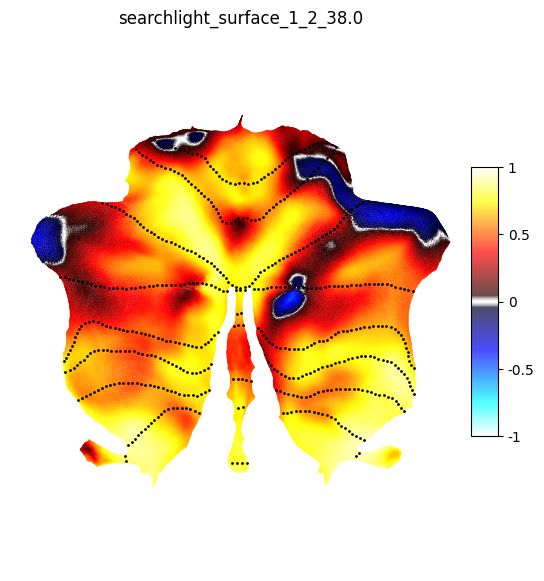

In [11]:

from mreyemove.analysis.glm.cli import construct_desc
import os
import nibabel as nib 
from SUITPy import flatmap

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original.yml")
desc_add = construct_desc(dataset=mrio, config=config)
output_dir = Path('/Users/zach/2025_RA/matthias/final images/group_level/cerebellum/')

state_1 = "1"
state_2 = "2"
radius_mm = 38.0
title = f"searchlight_surface_{state_1}_{state_2}_{radius_mm}"
surf_path = os.path.join(flatmap._base_dir,'surfaces', f'PIAL_FSL.surf.gii')
coords, faces = load_surf_mesh(surf_path)

vol_a,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_1}", desc_add=desc_add)
vol_b,_ = mrio.load_FLAME_result(contrast=f"mreyemove_{state_2}", desc_add=desc_add)


surf_a = flatmap.vol_to_surf(vol_a.t_stat, space='FSL')
surf_b = flatmap.vol_to_surf(vol_b.t_stat, space='FSL')

results = surface_searchlight_correlation(
    map_a_surf=surf_a,
    map_b_surf=surf_b,
    coords=coords,
    faces=faces,
    radius_mm=radius_mm,
    min_vertices=10,
)

ax = flatmap.plot(data=results, cmap=custom_cmap(), 
        new_figure=True, 
        colorbar=True, 
        render='matplotlib',
        cscale=[-1.0, 1.0])
ax.set_title(title)

output_path = output_dir / f"{title}.png"

ax.figure.savefig(output_path, format="png", dpi=300, bbox_inches="tight")


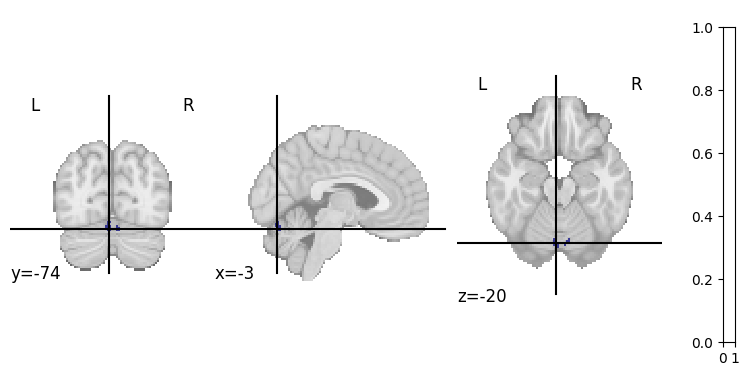

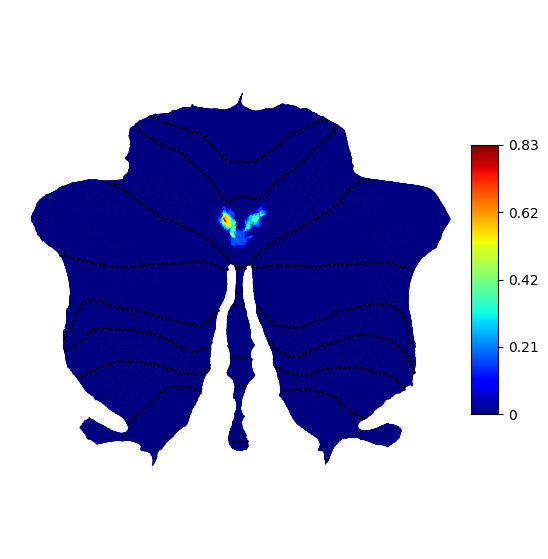

In [6]:
from matplotlib.patches import Patch
from matplotlib.colors import to_rgb
from matplotlib.colors import ListedColormap
from pathlib import Path
from mreyemove.plotting.glm import custom_cmap
from nilearn import image
# Import necessary packages
from nilearn import plotting
import nibabel as nib
from SUITPy import flatmap
import SUITPy as suit
from mreyemove.analysis.glm.atlas import fetch_atlas

atlas = fetch_atlas("cel_ret")

ROIS_TO_PLOT = {
    "OMV": [ "left_mOMV", "right_mOMV"] #, "left_lOMV",  "right_lOMV" ],
    # "VIIb": [ "left_VIIb", "right_VIIb" ],
    # "VIIIb": [ "left_mVIIIb", "left_lVIIIb", "right_mVIIIb", "right_lVIIIb" ],
}

cereb_data = atlas.maps.get_fdata()
combined = np.zeros(cereb_data.shape, dtype=np.int32)
roi_to_idx = {roi: i for i, roi in enumerate(atlas.labels, start=1)}

for plot_idx, plot_name in enumerate(ROIS_TO_PLOT, start=1):
  roi_ids = [roi_to_idx[roi_name] for roi_name in ROIS_TO_PLOT[plot_name]]
  combined[np.isin(cereb_data, roi_ids)] = plot_idx

combined_img = image.new_img_like(atlas.maps, combined, copy_header=True)


# colors = ["lightgray", "blue", "red", "yellow", "orange"]
# alpha = 1
# rgba_colors = [(*to_rgb(c), alpha) for c in colors]
# cmap = ListedColormap(rgba_colors)

n_rois = len(ROIS_TO_PLOT)
roi_names = list(ROIS_TO_PLOT.keys())

# legend_handles = [
#   Patch(facecolor=colors[i + 1], label=name)
#   for i, name in enumerate(roi_names)
# ]

plotting.plot_roi(combined_img)

funcdata = flatmap.vol_to_surf(combined_img, space='MNISymC')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)
# ax.legend(handles=legend_handles, loc="lower center", ncol=n_rois, fontsize=11)



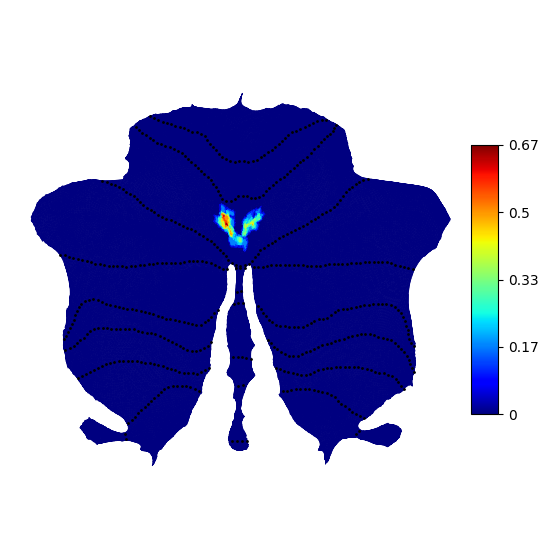

In [7]:
funcdata = flatmap.vol_to_surf(combined_img, space='FSL')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)

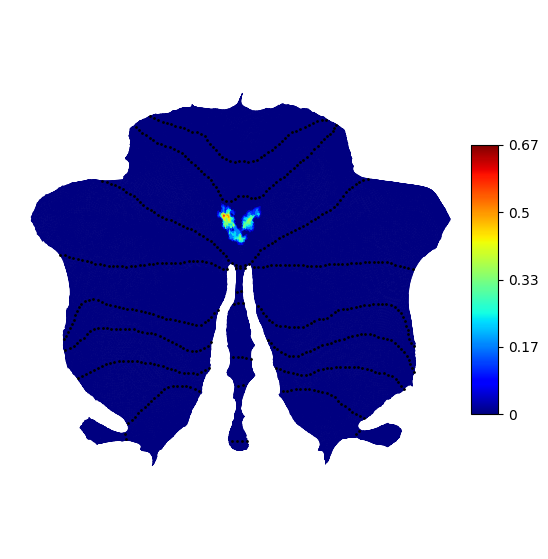

In [8]:
funcdata = flatmap.vol_to_surf(combined_img, space='SUIT')
# ax = flatmap.plot()
ax = flatmap.plot(data=funcdata, 
                  # cmap=cmap, 
    new_figure=True, 
    colorbar=True, 
    render='matplotlib',
)